In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ai4i2020.csv')

In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
train = df[['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]

In [8]:
test = df[['Machine failure']]

In [9]:
train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [10]:
test.head()

,Machine failure
0,0
1,0
2,0
3,0
4,0


In [11]:
xtrain, xtest, ytrain, ytest = train_test_split(train, test, test_size=0.2, random_state=36, stratify=test)

In [12]:
xtrain.shape

(8000, 6)

In [13]:
ytrain.shape

(8000, 1)

In [14]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
xtrain_type = encoder.fit_transform(xtrain[['Type']])
xtest_type = encoder.transform(xtest[['Type']])

In [15]:
print(xtrain_type)

[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 ...
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


In [16]:
print(xtest_type)

[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [17]:
encoder.get_feature_names_out(['Type'])

array(['Type_H', 'Type_L', 'Type_M'], dtype=object)

In [18]:
cols = encoder.get_feature_names_out(['Type'])
xtrain_type_df = pd.DataFrame(xtrain_type, columns=cols, index=xtrain.index)
xtest_type_df = pd.DataFrame(xtest_type, columns=cols, index=xtest.index)

In [19]:
xtrain_type_df.head()

,Type_H,Type_L,Type_M
6099,1.0,0.0,0.0
2511,0.0,0.0,1.0
5948,0.0,1.0,0.0
1031,0.0,1.0,0.0
4036,0.0,1.0,0.0


In [20]:
xtrain = xtrain.drop('Type', axis=1)
xtrain = pd.concat([xtrain, xtrain_type_df], axis=1)
xtest = xtest.drop('Type', axis=1)
xtest = pd.concat([xtest, xtest_type_df], axis=1)

In [21]:
xtrain.shape

(8000, 8)

In [22]:
xtest.shape

(2000, 8)

In [23]:
ytrain.shape

(8000, 1)

In [24]:
ytest.shape

(2000, 1)

In [25]:
xtrain.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
6099,300.9,310.7,1609,28.7,39,1.0,0.0,0.0
2511,299.0,308.9,1526,41.1,20,0.0,0.0,1.0
5948,300.7,310.8,2113,18.5,95,0.0,1.0,0.0
1031,296.4,307.5,1549,36.1,58,0.0,1.0,0.0
4036,302.0,310.8,1445,49.1,2,0.0,1.0,0.0


In [26]:
xtrain.dtypes

Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Type_H                     float64
Type_L                     float64
Type_M                     float64
dtype: object

In [27]:
xtrain.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,299.994575,309.998900,1538.365375,40.002087,108.086375,0.099625,0.601875,0.298500
std,1.993758,1.478418,179.838192,9.963280,63.537946,0.299518,0.489542,0.457629
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.300000,53.000000,0.000000,0.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,1.000000,0.000000
75%,301.500000,311.000000,1611.000000,46.700000,162.000000,0.000000,1.000000,1.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000


In [28]:
xtrain['Type_H'].value_counts()

Type_H
0.0    7203
1.0     797
Name: count, dtype: int64

In [29]:
xtrain['Type_L'].value_counts()

Type_L
1.0    4815
0.0    3185
Name: count, dtype: int64

In [30]:
xtrain['Type_M'].value_counts()

Type_M
0.0    5612
1.0    2388
Name: count, dtype: int64

In [31]:
ytrain.value_counts()

Machine failure
0                  7729
1                   271
Name: count, dtype: int64

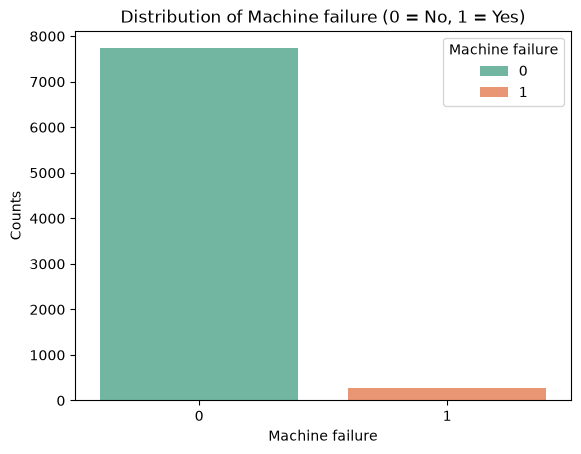

In [32]:
sns.countplot(x='Machine failure', data=ytrain, hue='Machine failure', palette='Set2')
plt.title('Distribution of Machine failure (0 = No, 1 = Yes)')
plt.xlabel('Machine failure')
plt.ylabel('Counts')
plt.show()

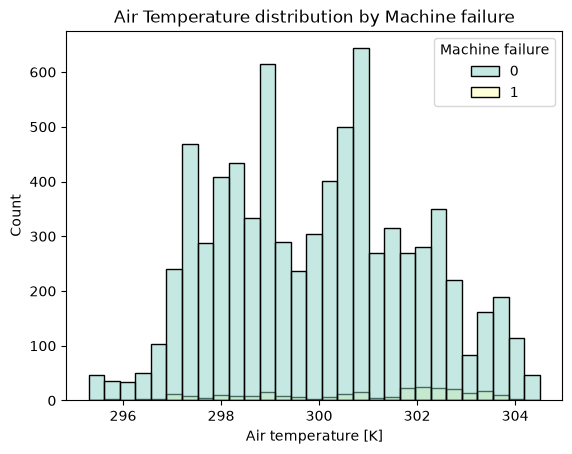

In [33]:
sns.histplot(x='Air temperature [K]', data=xtrain, hue=ytrain['Machine failure'], palette='Set3')
plt.title('Air Temperature distribution by Machine failure')
plt.show()

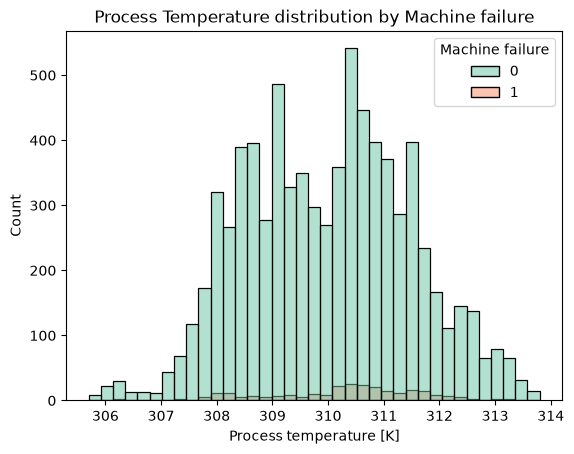

In [34]:
sns.histplot(x='Process temperature [K]', data=xtrain, hue=ytrain['Machine failure'], palette='Set2')
plt.title('Process Temperature distribution by Machine failure')
plt.show()

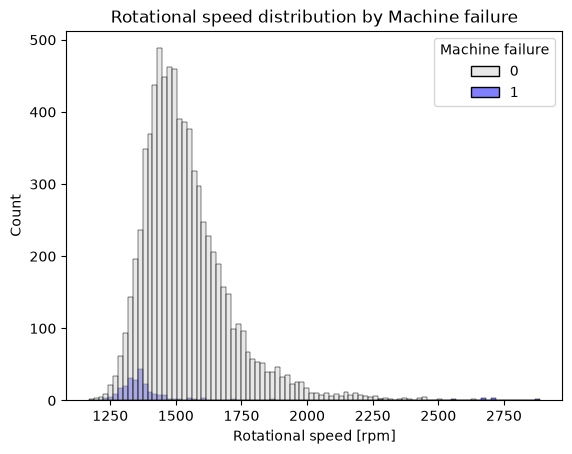

In [35]:
sns.histplot(x='Rotational speed [rpm]', data=xtrain, hue=ytrain['Machine failure'], palette=['lightgrey', 'blue'])
plt.title('Rotational speed distribution by Machine failure')
plt.show()

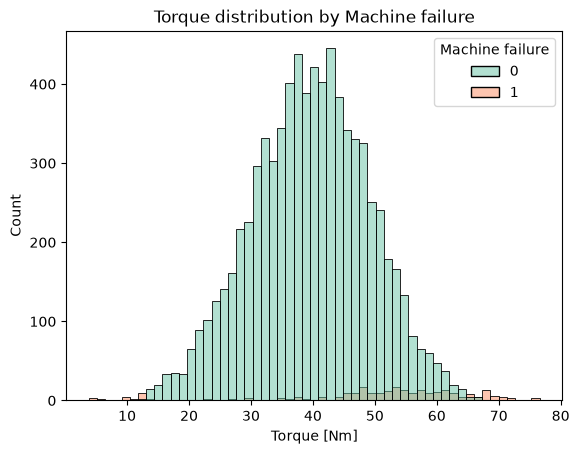

In [36]:
sns.histplot(x='Torque [Nm]', data=xtrain, hue=ytrain['Machine failure'], palette='Set2')
plt.title('Torque distribution by Machine failure')
plt.show()

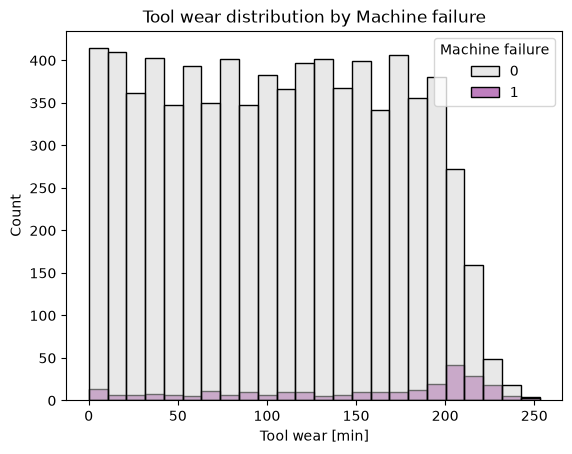

In [37]:
sns.histplot(x='Tool wear [min]', data=xtrain, hue=ytrain['Machine failure'], palette=['lightgrey', 'purple'])
plt.title('Tool wear distribution by Machine failure')
plt.show()

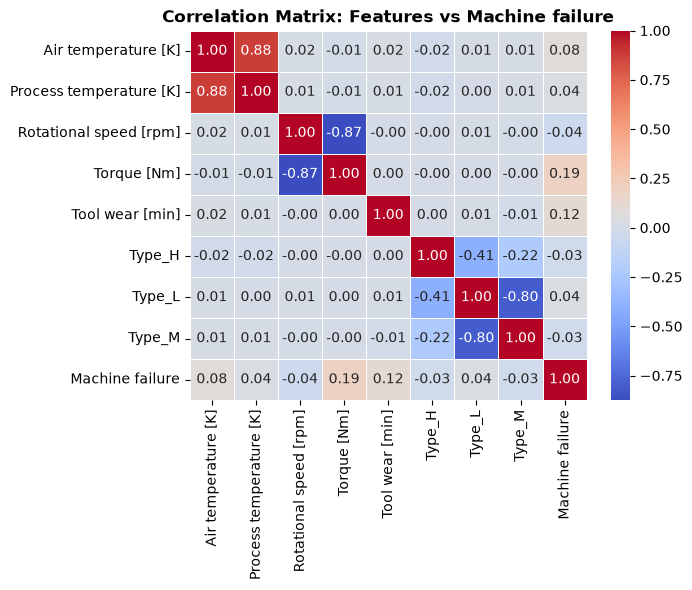

In [38]:
temp_df = pd.concat([xtrain, ytrain], axis=1)
corr = temp_df.corr()
sns.heatmap(corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix: Features vs Machine failure', fontweight='bold')
plt.show()

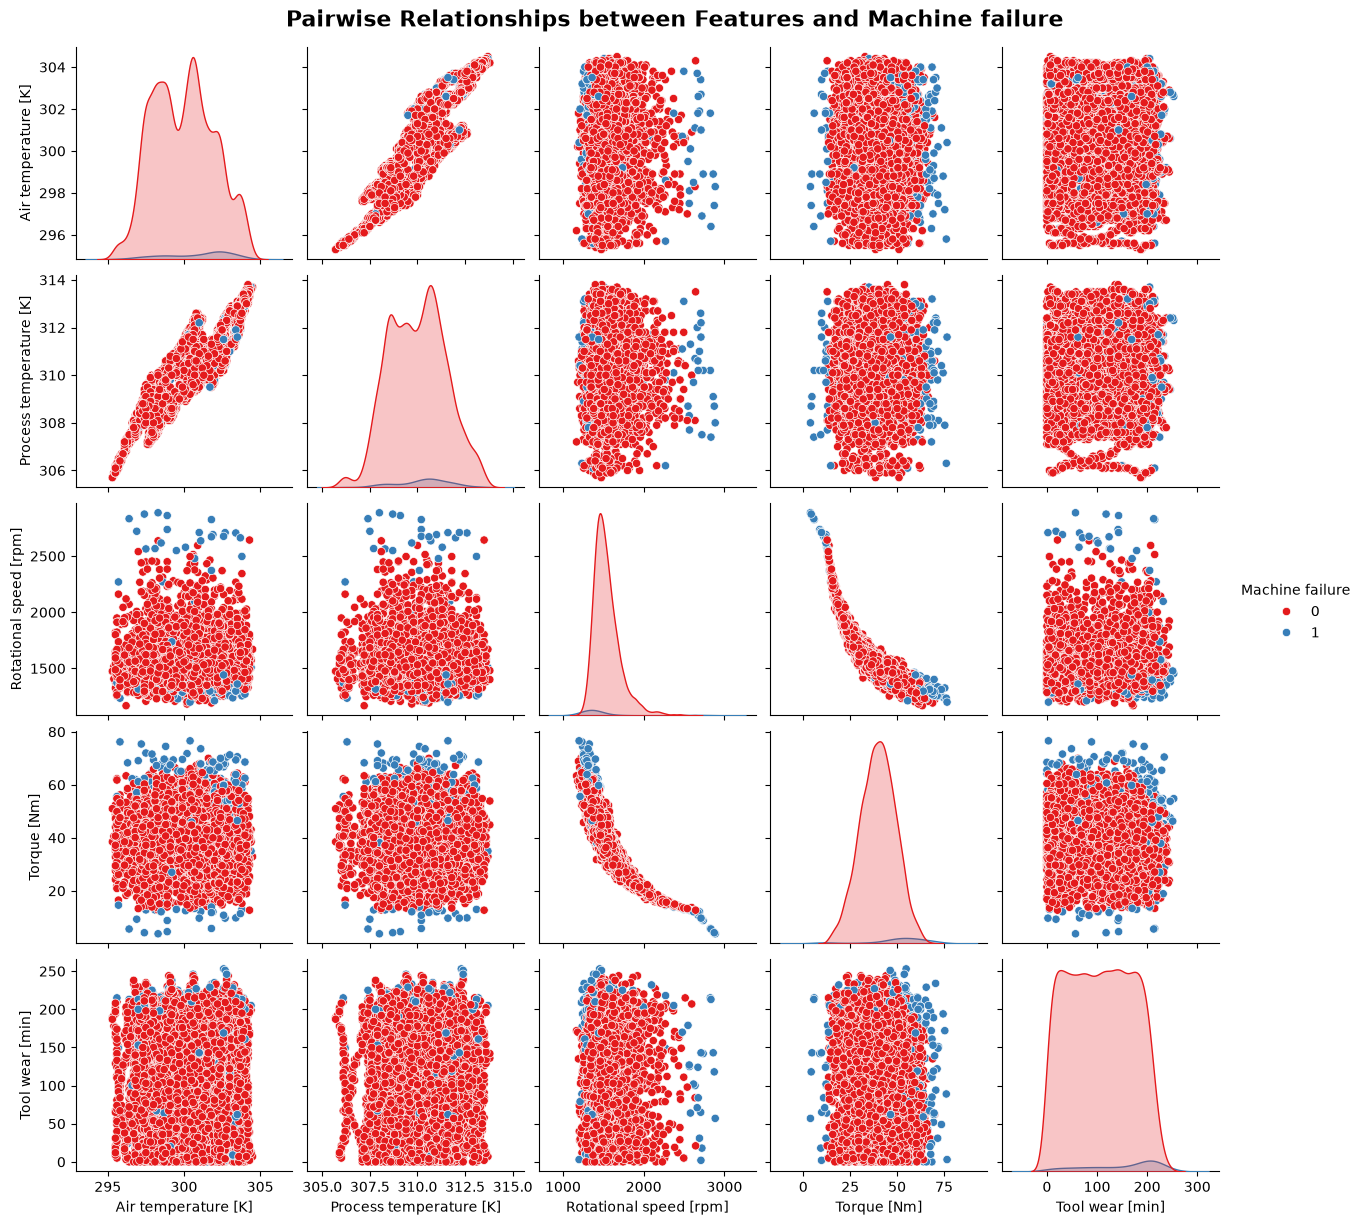

In [39]:
num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
sns.pairplot(temp_df, vars=num_cols, hue='Machine failure', palette='Set1')
plt.suptitle('Pairwise Relationships between Features and Machine failure', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95)
plt.show()

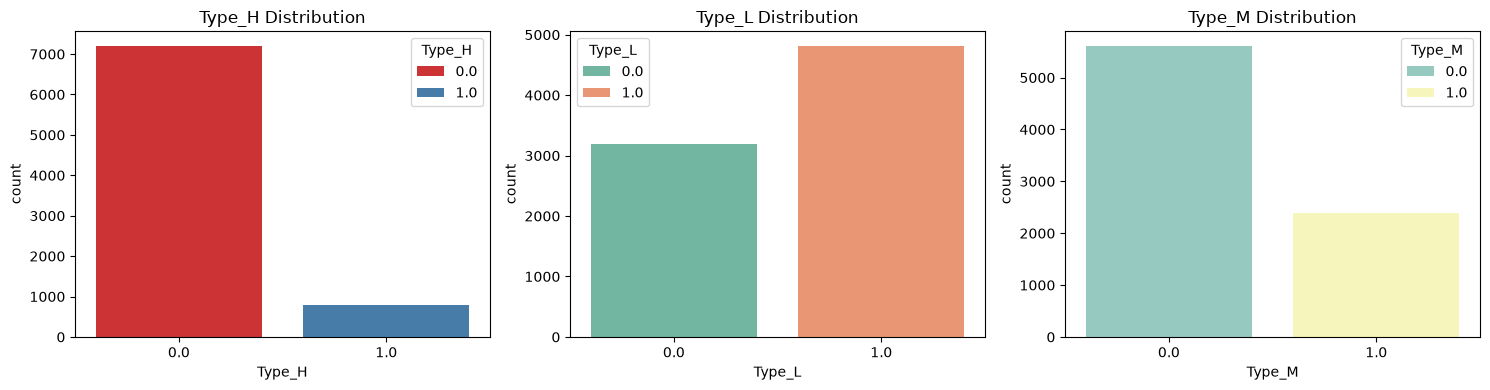

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(x='Type_H', data=xtrain, ax=axes[0], hue='Type_H', palette='Set1')
axes[0].set_title('Type_H Distribution')
sns.countplot(x='Type_L', data=xtrain, ax=axes[1], hue='Type_L', palette='Set2')
axes[1].set_title('Type_L Distribution')
sns.countplot(x='Type_M', data=xtrain, ax=axes[2], hue='Type_M', palette='Set3')
axes[2].set_title('Type_M Distribution')
plt.tight_layout()
plt.show()

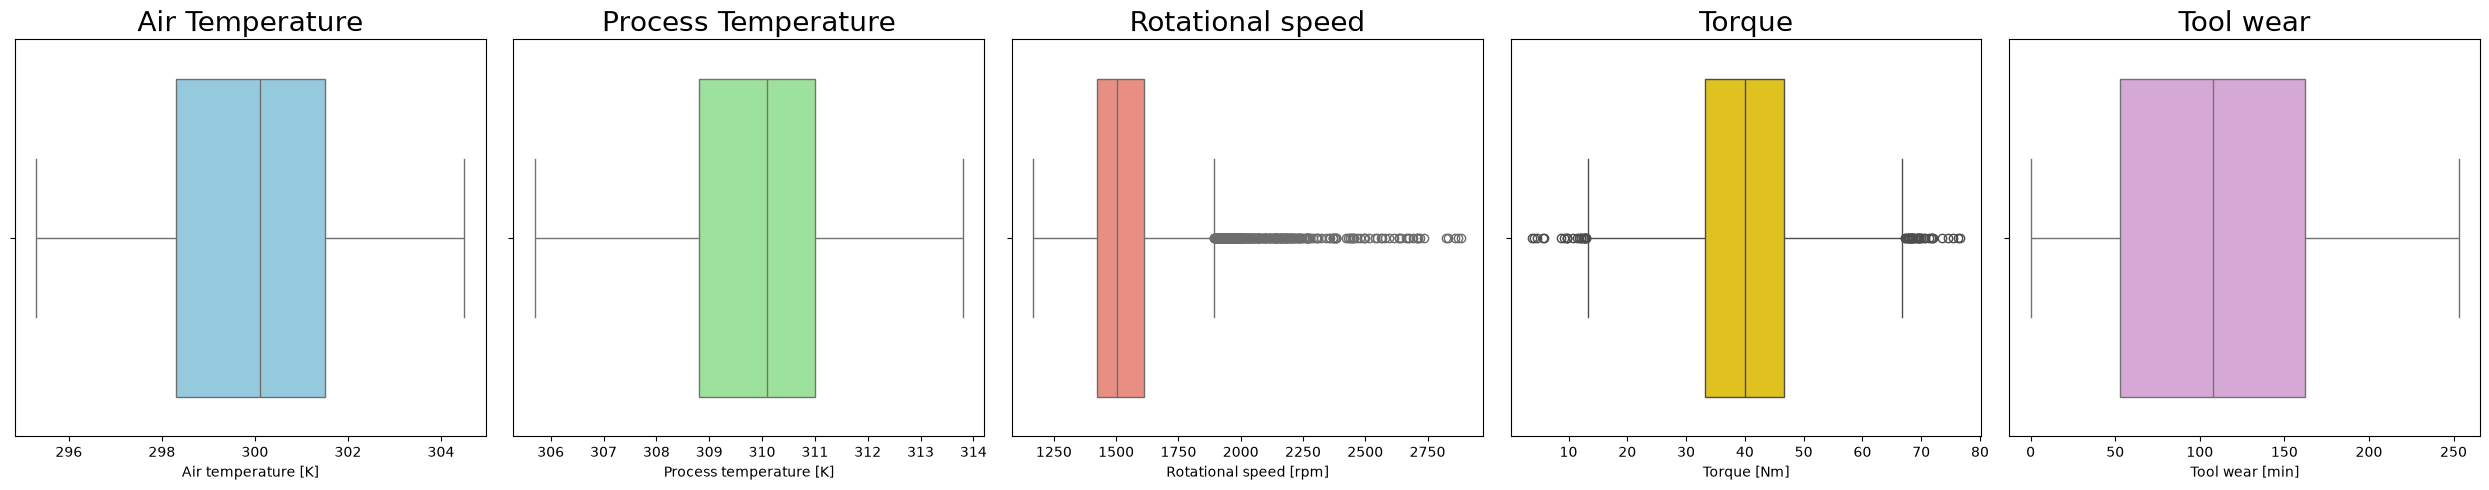

In [41]:
#Horizontal Boxplot
fig, axes=plt.subplots(1, 5, figsize=(25,5))  
sns.boxplot(x=xtrain['Air temperature [K]'], ax=axes[0], color='skyblue')  
axes[0].set_title('Air Temperature', size=20)
sns.boxplot(x=xtrain['Process temperature [K]'], ax=axes[1], color='lightgreen')
axes[1].set_title('Process Temperature', size=20)
sns.boxplot(x=xtrain['Rotational speed [rpm]'], ax=axes[2], color='salmon')
axes[2].set_title('Rotational speed', size=20)
sns.boxplot(x=xtrain['Torque [Nm]'], ax=axes[3], color='gold')
axes[3].set_title('Torque', size=20)
sns.boxplot(x=xtrain['Tool wear [min]'], ax=axes[4], color='plum')
axes[4].set_title('Tool wear', size=20)
plt.tight_layout()
plt.show()

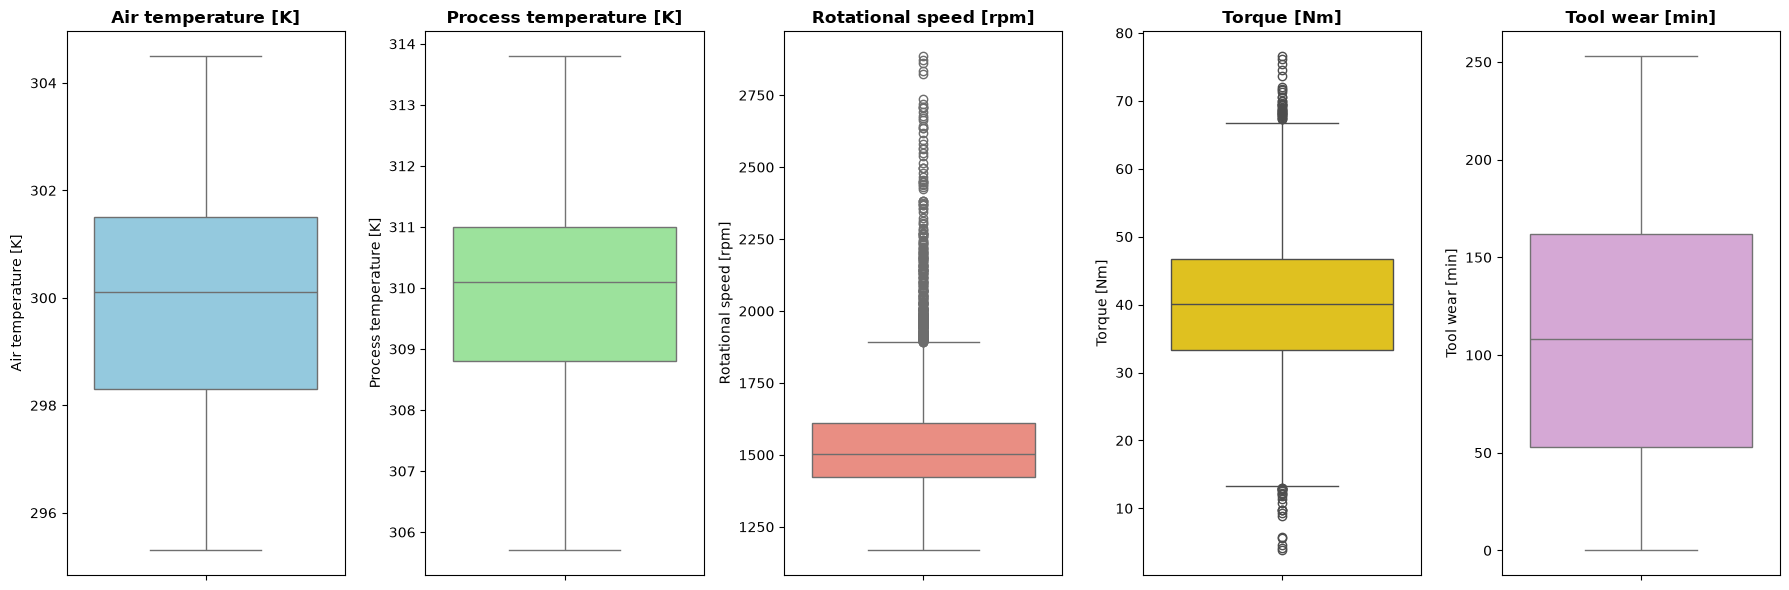

In [42]:
#Vertical Boxplot
num_cols = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold', 'plum']

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, col in enumerate(num_cols):
    sns.boxplot(y=xtrain[col], ax=axes[i], color=colors[i])  
    axes[i].set_title(col, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
from sklearn.preprocessing import StandardScaler
cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
st = StandardScaler()
xtrain_scaled = st.fit_transform(xtrain[cols])
xtest_scaled = st.transform(xtest[cols])
xtrain_scaled_df = pd.DataFrame(xtrain_scaled, columns=cols, index=xtrain.index)
xtest_scaled_df = pd.DataFrame(xtest_scaled, columns=cols, index=xtest.index)

In [44]:
xtrain = pd.concat([xtrain.drop(cols, axis=1), xtrain_scaled_df], axis=1)
xtest = pd.concat([xtest.drop(cols, axis=1), xtest_scaled_df], axis=1)

In [45]:
xtrain.head()

,Type_H,Type_L,Type_M,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
6099,1.0,0.0,0.0,0.454158,0.474253,0.392792,-1.134445,-1.087393
2511,0.0,0.0,1.0,-0.498875,-0.743341,-0.068763,0.110203,-1.386445
5948,0.0,1.0,0.0,0.353839,0.541897,3.195487,-2.158268,-0.205974
1031,0.0,1.0,0.0,-1.803027,-1.690358,0.059138,-0.391671,-0.788340
4036,0.0,1.0,0.0,1.005914,0.541897,-0.519196,0.913201,-1.669758


In [46]:
xtest.head()

,Type_H,Type_L,Type_M,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
668,0.0,1.0,0.0,-1.251270,-0.743341,1.110149,-1.606207,1.367987
7985,0.0,1.0,0.0,0.504318,1.488914,0.009090,-0.592421,0.077339
8527,0.0,1.0,0.0,-0.799833,-0.472765,-0.040958,-0.261184,-1.449404
7579,0.0,1.0,0.0,0.203360,0.812473,-0.569244,1.686088,1.021715
2597,0.0,1.0,0.0,-0.498875,-0.878629,-0.496952,-0.110622,-1.417924


In [47]:
xtrain.shape

(8000, 8)

In [48]:
xtest.shape

(2000, 8)

In [49]:
ytrain = ytrain.values.ravel()
ytrain.shape

(8000,)

In [50]:
ytest = ytest.values.ravel()
ytest.shape

(2000,)

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
def model_testing(model):
    model.fit(xtrain, ytrain)
    pred_val = model.predict(xtest)

    print('Accuracy score:', accuracy_score(ytest, pred_val))
    print('Classification report:', classification_report(ytest, pred_val))
    print('Confusion matrix:', confusion_matrix(ytest, pred_val))
    yprob = model.predict_proba(xtest)[:, 1]
    print('Roc_Auc_score:', roc_auc_score(ytest, yprob))

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [53]:
lg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg = model_testing(lg)

Accuracy score: 0.825
Classification report:               precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000

Confusion matrix: [[1594  338]
 [  12   56]]
Roc_Auc_score: 0.8990987699427597


In [54]:
dectree = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42, class_weight='balanced')
dt = model_testing(dectree)

Accuracy score: 0.924
Classification report:               precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.30      0.96      0.46        68

    accuracy                           0.92      2000
   macro avg       0.65      0.94      0.71      2000
weighted avg       0.97      0.92      0.94      2000

Confusion matrix: [[1783  149]
 [   3   65]]
Roc_Auc_score: 0.9589422725611984


In [55]:
k = KNeighborsClassifier(n_neighbors=5)
knn = model_testing(k)

Accuracy score: 0.9725
Classification report:               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.76      0.28      0.41        68

    accuracy                           0.97      2000
   macro avg       0.87      0.64      0.70      2000
weighted avg       0.97      0.97      0.97      2000

Confusion matrix: [[1926    6]
 [  49   19]]
Roc_Auc_score: 0.8111489160881743


In [56]:
ranfor = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42, class_weight='balanced')
rf = model_testing(ranfor)

Accuracy score: 0.9545
Classification report:               precision    recall  f1-score   support

           0       1.00      0.96      0.98      1932
           1       0.42      0.90      0.57        68

    accuracy                           0.95      2000
   macro avg       0.71      0.93      0.77      2000
weighted avg       0.98      0.95      0.96      2000

Confusion matrix: [[1848   84]
 [   7   61]]
Roc_Auc_score: 0.9687195530386068


In [57]:
grdboost = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
gb = model_testing(grdboost)

Accuracy score: 0.981
Classification report:               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.92      0.49      0.63        68

    accuracy                           0.98      2000
   macro avg       0.95      0.74      0.81      2000
weighted avg       0.98      0.98      0.98      2000

Confusion matrix: [[1929    3]
 [  35   33]]
Roc_Auc_score: 0.970573011813421


In [58]:
xtrain.columns = xtrain.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False)
xtest.columns = xtest.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False)

In [59]:
xgboost = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')
xgb = model_testing(xgboost)

Accuracy score: 0.987
Classification report:               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.96      0.65      0.77        68

    accuracy                           0.99      2000
   macro avg       0.97      0.82      0.88      2000
weighted avg       0.99      0.99      0.99      2000

Confusion matrix: [[1930    2]
 [  24   44]]
Roc_Auc_score: 0.9789154792351724


In [60]:
SVM = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42, class_weight='balanced')
svm = model_testing(SVM)

C:\Users\adnan\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy score: 0.909
Classification report:               precision    recall  f1-score   support

           0       1.00      0.91      0.95      1932
           1       0.26      0.93      0.41        68

    accuracy                           0.91      2000
   macro avg       0.63      0.92      0.68      2000
weighted avg       0.97      0.91      0.93      2000

Confusion matrix: [[1755  177]
 [   5   63]]
Roc_Auc_score: 0.9574998477651931


In [61]:
# I compared seven classification models using accuracy, classification report, confusion matrix and ROC-AUC. Since the dataset is imbalanced, 
# I didn't rely only on accuracy. I focused mainly on the minority failure class, especially precision, recall and F1-score. 
# XGBoost gave the highest F1-score of 0.67 and ROC-AUC of about 0.978, so I selected XGBoost as my final model.

In [62]:
from sklearn.model_selection import GridSearchCV
param_grids_xgb = {'max_depth' : [3, 4, 5],'subsample' : [0.8, 1.0],'colsample_bytree' : [0.8, 1.0],'n_estimators':[100, 200, 300],'learning_rate':[0.01, 0.05, 0.1], 'reg_lambda': [1, 5, 10], 'min_child_weight': [1, 5, 10]}
xgb = XGBClassifier(random_state=40, eval_metric='logloss')
grid = GridSearchCV(estimator=xgb, param_grid=param_grids_xgb, cv=5, scoring='f1', n_jobs=-1)
grid.fit(xtrain, ytrain)
print('Best Parameters:', grid.best_params_)
print('Best CV F1 Score:', grid.best_score_)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 1.0}
Best CV F1 Score: 0.7253746129455717


In [63]:
#1913 is Tn, 11 is Fp, Fn is 25 and Tp is 51 basically Tn is no failure where it predict no failure and Tp is failure where it predict failure.
# Fp is no failure where it predicts failure and Fn is failure where it predicts no failure
best_xgb = grid.best_estimator_
model_testing(best_xgb)

Accuracy score: 0.987
Classification report:               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.68      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000

Confusion matrix: [[1928    4]
 [  22   46]]
Roc_Auc_score: 0.9750258799171844


In [64]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(n_estimators=100, contamination=0.038, random_state=42)
iso.fit(xtrain)
anomaly_pred = iso.predict(xtest)

In [65]:
anomaly_pred[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [66]:
pd.Series(anomaly_pred).value_counts()

 1    1924
-1      76
Name: count, dtype: int64

In [67]:
anomaly_df = pd.DataFrame({'Actual failure': ytest, 'Anomaly prediction': anomaly_pred})
anomaly_df.head(50)

,Actual failure,Anomaly prediction
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


In [68]:
anomaly_df['Anomaly'] = (anomaly_df['Anomaly prediction'] == -1).astype(int)
anomaly_df.head()

,Actual failure,Anomaly prediction,Anomaly
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [69]:
pd.crosstab(anomaly_df['Actual failure'], anomaly_df['Anomaly'])

Anomaly,0,1
Actual failure,,
0,1866,66
1,58,10


In [70]:
anomaly_score = iso.decision_function(xtest)
anomaly_score[:20]

array([0.08799832, 0.15759606, 0.15987699, 0.13741114, 0.15127819,
       0.140056  , 0.14623413, 0.17228368, 0.04996768, 0.03070767,
       0.12268639, 0.10597331, 0.08010671, 0.04953591, 0.1470127 ,
       0.05257956, 0.15170133, 0.02805606, 0.14869241, 0.13460914])

In [71]:
anomaly_df['Anomaly Score'] = anomaly_score
anomaly_df.head()

,Actual failure,Anomaly prediction,Anomaly,Anomaly Score
0,0,1,0,0.087998
1,0,1,0,0.157596
2,0,1,0,0.159877
3,0,1,0,0.137411
4,0,1,0,0.151278


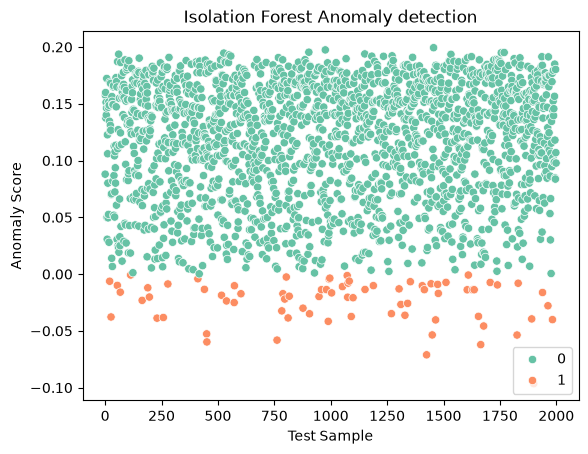

In [72]:
sns.scatterplot(x=anomaly_df.index, y=anomaly_df['Anomaly Score'], hue=anomaly_df['Anomaly'], palette='Set2')
plt.xlabel('Test Sample')
plt.ylabel('Anomaly Score')
plt.title('Isolation Forest Anomaly detection')
plt.legend(loc='lower right')
plt.show()

In [73]:
from sklearn.metrics import f1_score
train_pred = best_xgb.predict(xtrain)
print('Train F1:', f1_score(ytrain, train_pred))
print('Train Roc-Auc score:', roc_auc_score(ytrain, best_xgb.predict_proba(xtrain)[:,1]))

Train F1: 0.9536679536679536
Train Roc-Auc score: 0.9996362002693645


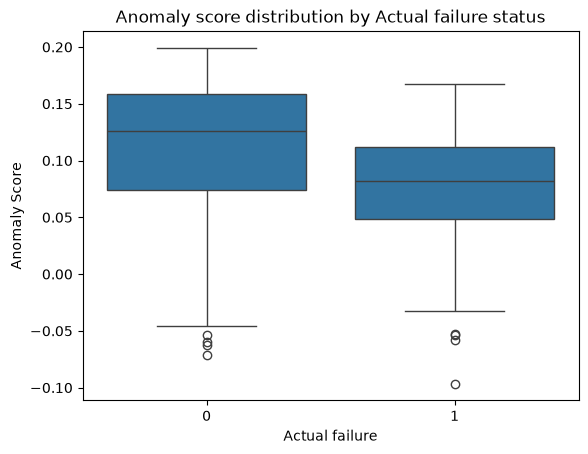

In [75]:
sns.boxplot(x='Actual failure', y='Anomaly Score', data=anomaly_df)
plt.title('Anomaly score distribution by Actual failure status')
plt.show()

In [76]:
import joblib
joblib.dump(best_xgb, 'xgb_failure_model.joblib')
joblib.dump(iso, 'isolation_forest_model.joblib')
joblib.dump(st, 'scaler.joblib')
joblib.dump(encoder, 'onehot_encoder.joblib')

['onehot_encoder.joblib']

## *Conclusion*

Built a predictive maintenance and anomaly detection pipeline on the AI4I 2020 industrial sensor dataset (temperature, torque, tool wear, rotational speed).

- *Preprocessing:* Applied One-Hot Encoding and StandardScaler (fit on train only, to avoid data leakage).
- *Model Comparison:* Evaluated 7 classification models (Logistic Regression through XGBoost, SVM) using precision/recall/F1/ROC-AUC instead of accuracy, since the failure class was highly imbalanced (~3.3%).
- *Best Model:* XGBoost performed best and was tuned further with GridSearchCV, improving minority-class F1 from *0.67 → 0.78*.
- *Overfitting Check:* Compared train vs. test performance — found a gap (train F1 *0.95* vs test F1 *0.78*) and addressed it by adding regularization parameters to the tuning grid.
- *Anomaly Detection:* Added an Isolation Forest model as a complementary unsupervised approach to flag anomalous sensor readings independent of labeled failure data, with contamination set to match the real failure rate.
- *Deployment:* Saved the final model, scaler, encoder, and anomaly detector using joblib for deployment via FastAPI, with prediction logging planned through PostgreSQL.